## Hyperparameter Tuning

#### =============================================================
#### Part 1: Linear Regression
#### Dataset: HousePrice_Data2.csv
#### =============================================================

This dataset is designed for predicting house prices. It contains 1000 rows, with each row representing a house and various attributes that influence its price.

Features:
- Square_Footage: The size of the house in square feet. Larger homes typically have higher prices.
- Num_Bedrooms: The number of bedrooms in the house. More bedrooms generally increase the value of a home.
- Num_Bathrooms: The number of bathrooms in the house. Houses with more bathrooms are typically priced higher.
- Year_Built: The year the house was built. Older houses may be priced lower due to wear and tear.
- Lot_Size: The size of the lot the house is built on, measured in acres. Larger lots tend to add value to a property.
- Garage_Size: The number of cars that can fit in the garage. Houses with larger garages are usually more expensive.
- Neighborhood_Quality: A rating of the neighborhood’s quality on a scale of 1-10, where 10 indicates a high-quality neighborhood. Better neighborhoods usually command higher prices.
- House_Price (Target Variable): The price of the house, which is the dependent variable you aim to predict.

Ref: Kaggle Dataset https://www.kaggle.com/datasets/prokshitha/home-value-insights

In [1]:
# ==============================
# Step 1: Import libraries
# ==============================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
# ==============================
# Step 2: Load the Dataset
# ==============================

# Load dataset
data = pd.read_csv("https://raw.githubusercontent.com/SKY-TKP/Machine-Learning-for-IE/refs/heads/main/2104-305%3A%20INTRO%20MAC%20LANG%20IE/Coding%20Tutorial/L4%3A%20Hyper-parameter%20Tuning/Data/HousePrice_Data2.csv")

# Display first few rows
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
# ==============================
# Step 3: Separate Features and Target
# ==============================

# Features (all columns except the last one)
X = data.iloc[:, :-1]

# Target (Home_Price)
y = data.iloc[:, -1]

In [4]:
# ==============================
# Step 4: Train / Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,                        # Feature matrix
    y,                        # Class labels
    test_size = 0.2,          # Use 20% of data as test set
    random_state = 42,        # Fix random seed for reproducibility
)

In [5]:
# ==============================
# Step 5: Ridge Regression WITHOUT Hyperparameter Tuning (using default hyperparameter settings)
# ==============================

# Create a pipeline with feature scaling and Ridge regression
ridge_default = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())          # Ridge Regression = Linear Regression + L2 regularization
])

# Train the model
ridge_default.fit(X_train, y_train)

# Predictions
y_train_pred = ridge_default.predict(X_train)
y_test_pred = ridge_default.predict(X_test)

# Evaluation
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

default_results = pd.DataFrame({
    "Metric": ["Train RMSE", "Test RMSE", "Test R2"],
    "Value": [train_rmse, test_rmse, test_r2]
})

default_results

,Metric,Value
0,Train RMSE,9692.806381
1,Test RMSE,10123.289483
2,Test R2,0.998410


In [6]:
# ==============================
# Step 6: Ridge Regression WITH Hyperparameter Tuning (GridSearchCV)
# ==============================

# We tune hyperparameters using k-fold cross-validation on the training set.

# Hyperparameters to Tune
# alpha : regularization strength
# solver : optimization method

# Define pipeline
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

# Define hyperparameter grid
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100],               # alpha controls the strength of L2 regularization
    "ridge__solver": ["auto", "svd", "cholesky", "lsqr"]   # solver specifies the numerical method used to solve the Ridge optimization problem
}

In [7]:
# ==============================
# Step 7: GridSearchCV
# ==============================

grid_search = GridSearchCV(
    estimator = ridge,                    # Ridge regression model pipeline
    param_grid = param_grid,              # Hyperparameter values to try
    scoring = "neg_mean_squared_error",   # Use MSE as evaluation metric (negated by scikit-learn)
    cv = 5,                               # 5-fold cross-validation
    n_jobs = -1                           # Use all available CPU cores
)

# Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'ridge__alpha': [0.01, 0.1, 1, 10, 100],
                         'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr']},
             scoring='neg_mean_squared_error')

In [8]:
# ==============================
# Step 8: Best Hyperparameters
# ==============================

pd.DataFrame(
    grid_search.best_params_.items(),
    columns = ["Hyperparameter", "Best Value"]
)

,Hyperparameter,Best Value
0,ridge__alpha,0.01
1,ridge__solver,lsqr


In [9]:
# ==============================
# Step 8.1: Best CV Score
# ==============================

# Best CV score (convert from negative MSE)
best_cv_rmse = np.sqrt(-grid_search.best_score_)

pd.DataFrame({
    "Metric": ["Best CV RMSE"],
    "Value": [best_cv_rmse]
})

,Metric,Value
0,Best CV RMSE,9755.853112


In [10]:
# ==============================
# Step 9: Evaluate Tuned Model on Test Set
# ==============================

# Best model selected by GridSearchCV
best_model = grid_search.best_estimator_          # Model with best hyperparameters

# Generate predictions on the test set
y_test_pred_tuned = best_model.predict(X_test)    # Predict target values for test data

# Compute evaluation metrics
test_rmse_tuned = np.sqrt(
    mean_squared_error(y_test, y_test_pred_tuned) # Root Mean Squared Error on test set
)

test_r2_tuned = r2_score(
    y_test, y_test_pred_tuned                     # R-squared score on test set
)

test_results_df = pd.DataFrame({
    "Metric": ["Test RMSE", "Test R2"],
    "Value": [test_rmse_tuned, test_r2_tuned]
})

test_results_df

,Metric,Value
0,Test RMSE,10071.880578
1,Test R2,0.998426


In [11]:
# ==============================
# Step 10: Compare Results (Before vs After Tuning)
# ==============================

results = pd.DataFrame({
    "Model": ["Ridge (Default)", "Ridge (Tuned)"],
    "Test RMSE": [test_rmse, test_rmse_tuned],
    "Test R2": [test_r2, test_r2_tuned]
})

results

,Model,Test RMSE,Test R2
0,Ridge (Default),10123.289483,0.998410
1,Ridge (Tuned),10071.880578,0.998426


#### =============================================================
#### Part 2: Logistic Regression
#### Dataset: DryBean_Data.csv
#### =============================================================

Seven different types of dry beans were used in this part, taking into account the features such as form, shape, type, and structure by the market situation. A computer vision system was developed to distinguish seven different registered varieties of dry beans with similar features in order to obtain uniform seed classification. For the classification model, images of 13,611 grains of 7 different registered dry beans were taken with a high-resolution camera. Bean images obtained by computer vision system were subjected to segmentation and feature extraction stages, and a total of 16 features; 12 dimensions and 4 shape forms, were obtained from the grains.

Ref: Kaggle Dataset https://www.kaggle.com/datasets/nimapourmoradi/dry-bean-dataset-classification

In [12]:
# ==============================
# Step 1: Import libraries
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from IPython.display import display

In [13]:
# ==============================
# Step 2: Load the Dataset
# ==============================

# Load dataset
data = pd.read_csv("https://raw.githubusercontent.com/SKY-TKP/Machine-Learning-for-IE/refs/heads/main/2104-305%3A%20INTRO%20MAC%20LANG%20IE/Coding%20Tutorial/L4%3A%20Hyper-parameter%20Tuning/Data/DryBean_Data.csv")

# Display first few rows
data.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Type
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [14]:
# ==============================
# Step 3: Separate Features and Target
# ==============================

# Features: all columns except the last one
X = data.iloc[:, :-1]

# Target: bean type (categorical labels)
y = data.iloc[:, -1]

# Count number of samples in each class
class_counts = y.value_counts().reset_index()

# Rename columns for clarity
class_counts.columns = ["Class", "Count"]

class_counts

,Class,Count
0,DERMASON,3546
1,SIRA,2636
2,SEKER,2027
3,HOROZ,1928
4,CALI,1630
5,BARBUNYA,1322
6,BOMBAY,522


In [15]:
# ==============================
# Step 4: Encode Class Labels
# ==============================

# Create a label encoder to convert class names to numbers
label_encoder = LabelEncoder()                             # Initialize label encoder

# Encode string labels into numeric values
y_encoded = label_encoder.fit_transform(y)                 # Transform class labels to integers

# Create a dictionary showing original class names and their encoded values
label_mapping = dict(
    zip(
        label_encoder.classes_,                             # Original class labels
        label_encoder.transform(label_encoder.classes_)     # Corresponding encoded values
    )
)

label_mapping                                              # Display label mapping

{'BARBUNYA': np.int64(0),
 'BOMBAY': np.int64(1),
 'CALI': np.int64(2),
 'DERMASON': np.int64(3),
 'HOROZ': np.int64(4),
 'SEKER': np.int64(5),
 'SIRA': np.int64(6)}

In [16]:
# ==============================
# Step 5: Train / Test Split (Stratified)
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,                        # Feature matrix
    y_encoded,                # Encoded class labels
    test_size = 0.2,          # Use 20% of data as test set
    random_state = 42,        # Fix random seed for reproducibility
    stratify = y_encoded      # Preserve class proportions in both sets
)

In [17]:
# ==============================
# Step 6: Logistic Regression WITHOUT Hyperparameter Tuning
# ==============================

# Create pipeline: feature scaling + logistic regression
log_reg_default = Pipeline([
    ("scaler", StandardScaler()),              # Standardize input features
    ("logreg", LogisticRegression(
        max_iter = 1000,                       # Maximum number of iterations
        random_state = 42                      # Fix random seed
    ))
])

# Train the logistic regression model
log_reg_default.fit(X_train, y_train)          # Fit model using training data

# Generate predictions on the test set
y_test_pred_default = log_reg_default.predict(X_test)  # Predict class labels

# Evaluate model accuracy
default_accuracy = accuracy_score(
    y_test, y_test_pred_default                # Accuracy on test set
)

print('Default accuracy:', default_accuracy)

print()

# Display detailed classification metrics
print('Classification Report (Default model)')
print(classification_report(
    y_test,                                     # True labels
    y_test_pred_default,                        # Predicted labels
    target_names = label_encoder.classes_       # Original class names
))

Default accuracy: 0.9206757253029747

Classification Report (Default model)
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [18]:
# ==============================
# Step 7: Logistic Regression WITH Hyperparameter Tuning (GridSearchCV)
# ==============================

# Define pipeline
log_reg = Pipeline([
    ("scaler", StandardScaler()),          # Standardize input features
    ("logreg", LogisticRegression(
        max_iter = 1000,                   # Maximum number of iterations
        random_state = 42                  # Fix random seed
    ))
])

# Define hyperparameter grid
param_grid = [
    {
        "logreg__penalty": ["l2"],         # penalty: L2 regularization
        "logreg__solver": ["lbfgs", "newton-cg", "saga"],    # solver: optimization algorithm
        "logreg__C": [0.01, 0.1, 1, 10]    # C: inverse of regularization strength
    },
    {
        "logreg__penalty": ["l1"],         # penalty: L1 regularization
        "logreg__solver": ["saga"],        # solver: optimization algorithm
        "logreg__C": [0.01, 0.1, 1, 10]    # C: inverse of regularization strength
    }
]

# Note: "lbfgs" and "newton-cg" do not support "l1" penalty
# so we have to perform grid search for "l1" and "l2" separately

In [19]:
# ==============================
# Step 7.1: GridSearchCV
# ==============================

grid_search = GridSearchCV(
    estimator = log_reg,        # Logistic regression pipeline
    param_grid = param_grid,    # Hyperparameter values to evaluate
    scoring = "accuracy",       # Use accuracy as evaluation metric
    cv = 5,                     # 5-fold cross-validation
    n_jobs = -1                 # Use all available CPU cores
)

# For classification, scikit-learn automatically uses stratified k-fold cross-validation inside GridSearchCV.

# Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid=[{'logreg__C': [0.01, 0.1, 1, 10],
                          'logreg__penalty': ['l2'],
                          'logreg__solver': ['lbfgs', 'newton-cg', 'saga']},
                         {'logreg__C': [0.01, 0.1, 1, 10],
                          'logreg__penalty': ['l1'],
                          'logreg__solver': ['saga']}],
             scoring='accuracy')

In [20]:
# ==============================
# Step 7.2: Best Hyperparameters
# ==============================

# Best hyperparameters
pd.DataFrame(
    grid_search.best_params_.items(),
    columns = ["Hyperparameter", "Best Value"]
)

,Hyperparameter,Best Value
0,logreg__C,10
1,logreg__penalty,l2
2,logreg__solver,lbfgs


In [21]:
# ==============================
# Step 7.3: Best CV Score
# ==============================

# Best CV accuracy
best_cv_accuracy = grid_search.best_score_

pd.DataFrame({
    "Metric": ["Best CV accuracy"],
    "Value": [best_cv_accuracy]
})

,Metric,Value
0,Best CV accuracy,0.925331


In [22]:
# ==============================
# Step 7.3: Evaluate Tuned Model on Test Set
# ==============================

# Best model from GridSearchCV
best_model = grid_search.best_estimator_

# Predictions
y_test_pred_tuned = best_model.predict(X_test)

# Evaluation
tuned_accuracy = accuracy_score(y_test, y_test_pred_tuned)
print('Tuned accuracy:', tuned_accuracy)

print()

# Classification report (Tuned model)
print('Classification Report (Tuned model)')
print(classification_report(
    y_test,
    y_test_pred_tuned,
    target_names = label_encoder.classes_
))

Tuned accuracy: 0.9206757253029747

Classification Report (Tuned model)
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.88      0.92       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.97      0.94      0.95       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.84      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



,Model,Test Accuracy
0,Logistic Regression (Default),0.920676
1,Logistic Regression (Tuned),0.920676


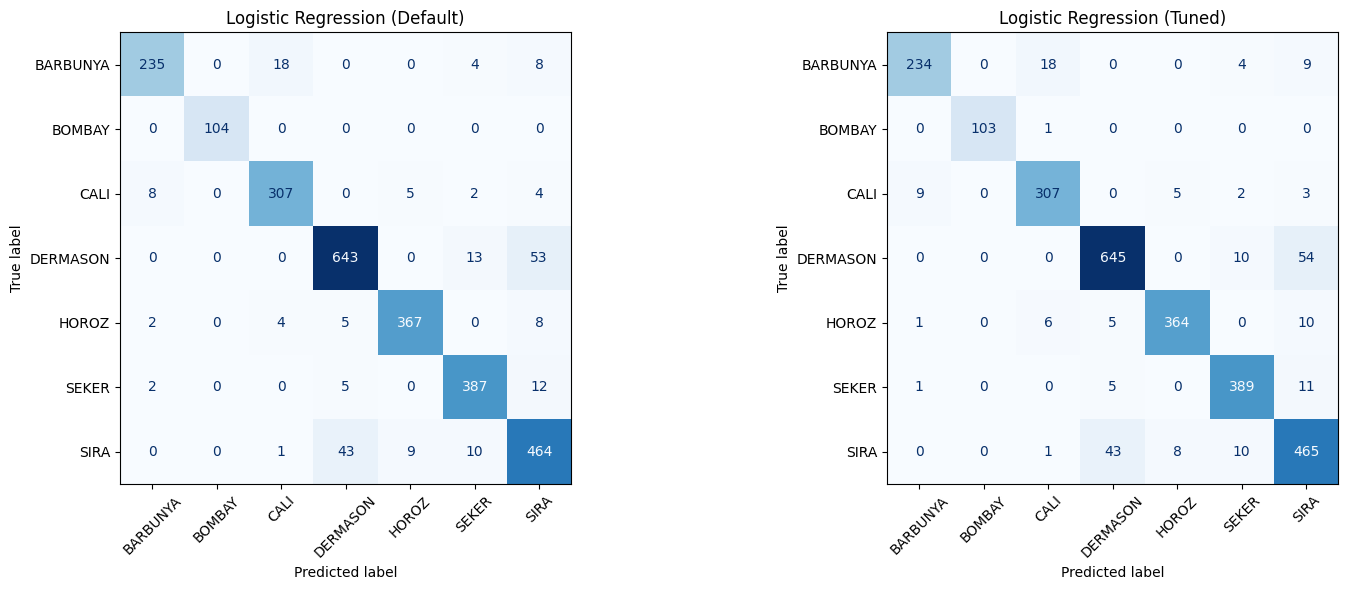

In [23]:
# ==============================
# Step 8: Compare Results (Before vs After Tuning)
# ==============================

# Create a DataFrame to compare test accuracy of both models
results = pd.DataFrame({
    "Model": ["Logistic Regression (Default)", "Logistic Regression (Tuned)"],
    "Test Accuracy": [default_accuracy, tuned_accuracy]
})

display(results)               # Display accuracy comparison table

print()

# Create side-by-side confusion matrix plots
fig, axes = plt.subplots(
    1, 2, figsize = (16, 6)                       # Two plots in one row
)

# Confusion matrix for the default logistic regression model
ConfusionMatrixDisplay.from_predictions(
    y_test,                                       # True labels
    y_test_pred_default,                          # Predictions from default model
    display_labels = label_encoder.classes_,      # Original class names
    cmap = "Blues",                               # Color map
    xticks_rotation = 45,                         # Rotate x-axis labels
    ax = axes[0],                                 # Plot on first subplot
    colorbar = False                              # Remove color bar
)
axes[0].set_title("Logistic Regression (Default)")  # Title for first plot

# Confusion matrix for the tuned logistic regression model
ConfusionMatrixDisplay.from_predictions(
    y_test,                                       # True labels
    y_test_pred_tuned,                            # Predictions from tuned model
    display_labels = label_encoder.classes_,      # Original class names
    cmap = "Blues",                               # Color map
    xticks_rotation = 45,                         # Rotate x-axis labels
    ax = axes[1],                                 # Plot on second subplot
    colorbar = False                              # Remove color bar
)
axes[1].set_title("Logistic Regression (Tuned)")  # Title for second plot

plt.tight_layout()                                # Adjust layout to prevent overlap
plt.show()

#### =============================================================
#### Part 3: Neural Network (for Regression Problem)
#### Dataset: Generated Dataset
#### =============================================================

In [24]:
# ==============================
# Step 1: Import libraries
# ==============================

import numpy as np
import pandas as pd

# Neural network model
from sklearn.neural_network import MLPRegressor

# Preprocessing and pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model selection tools
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt

In [25]:
# ==============================
# Step 2: Generate Synthetic Time Series Dataset
# ==============================

# Fix random seed for reproducibility
np.random.seed(42)

# Number of samples (about 6 months of hourly data)
n_samples = 24 * 180

# Time index
time = np.arange(n_samples)

# Generate features with seasonal patterns
temperature = 20 + 10 * np.sin(2 * np.pi * time / 24) + np.random.normal(0, 1, n_samples)
humidity = 60 + 20 * np.sin(2 * np.pi * time / (24 * 7)) + np.random.normal(0, 3, n_samples)

hour = time % 24
day_of_week = (time // 24) % 7
month = (time // (24 * 30)) % 12 + 1

# Generate target variable (electricity demand)
demand = (
    50
    + 2.5 * temperature
    - 1.2 * humidity
    + 10 * np.sin(2 * np.pi * hour / 24)
    + 5 * (day_of_week >= 5)
    + 0.01 * time
    + np.random.normal(0, 5, n_samples)
)

# Create DataFrame
data = pd.DataFrame({
    "Temperature": temperature,
    "Humidity": humidity,
    "Hour": hour,
    "DayOfWeek": day_of_week,
    "Month": month,
    "Demand": demand
})

data.head()

,Temperature,Humidity,Hour,DayOfWeek,Month,Demand
0,20.496714,59.940379,0,0,1,37.398555
1,22.449926,60.426030,1,0,1,32.359646
2,25.647689,65.155451,2,0,1,46.669488
3,28.594098,59.009252,3,0,1,58.699503
4,28.426101,60.693288,4,0,1,58.194535


In [26]:
# ==============================
# Step 3: Separate Features and Target
# ==============================

# Input features
X = data.drop(columns = ["Demand"])

# Target variable
y = data["Demand"]

In [27]:
# ==============================
# Step 4: Train / Test Split (Time-Based)
# ==============================

# for time series data, we must not shuffle.

# Determine split index
split_index = int(len(data) * 0.8)  # First 80% → Training, last 20% → Test (future data)

# Time-based split
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]   # Feature split
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]   # Target split

shape_df = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [
        X_train.shape,
        X_test.shape,
        y_train.shape,
        y_test.shape
    ]
})

shape_df

,Dataset,Shape
0,X_train,"(3456, 5)"
1,X_test,"(864, 5)"
2,y_train,"(3456,)"
3,y_test,"(864,)"


In [28]:
# ==============================
# Step 5: Define TimeSeriesSplit for CV
# ==============================

# TimeSeriesSplit ensures training data always comes before validation data
tscv = TimeSeriesSplit(n_splits = 5)   # Split data into 5 sequential folds

In [29]:
# ==============================
# Step 6: Neural Network WITHOUT Hyperparameter Tuning
# ==============================

# Build pipeline: feature scaling + neural network regressor
mlp_default = Pipeline([
    ("scaler", StandardScaler()),            # Standardize input features
    ("mlp", MLPRegressor(
        hidden_layer_sizes = (50, 50),       # Two hidden layers with 50 neurons each
        max_iter = 500,                      # Maximum number of training iterations
        random_state = 42                    # Fix random seed
    ))
])

# Train neural network on training data
mlp_default.fit(X_train, y_train)            # Fit model to training set

# Generate predictions on the test set
y_test_pred_default = mlp_default.predict(X_test) # Predict target values

# Compute evaluation metrics
default_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_default)  # Root Mean Squared Error
)

default_r2 = r2_score(
    y_test, y_test_pred_default                      # R-squared score
)

# Store results in DataFrame format
default_results = pd.DataFrame({
    "Metric": ["RMSE", "R2"],
    "Value": [default_rmse, default_r2]
})

default_results

,Metric,Value
0,RMSE,5.798147
1,R2,0.965930


In [30]:
# ==============================
# Step 7: Grid Search with TimeSeriesSplit
# ==============================

# Base pipeline defining preprocessing and model structure
mlp = Pipeline([
    ("scaler", StandardScaler()),      # Standardize input features
    ("mlp", MLPRegressor(
        max_iter = 800,                # Maximum number of training iterations
        random_state = 42              # Fix random seed
    ))
])

# Hyperparameter grid (all combinations will be evaluated)
param_grid = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (50, 50)],  # Network architectures
    "mlp__activation": ["relu", "tanh"],                   # Activation functions
    "mlp__alpha": [0.0001, 0.001, 0.01]                    # L2 regularization strengths
}

# Configure GridSearchCV
grid_search = GridSearchCV(
    estimator = mlp,                        # Neural network pipeline
    param_grid = param_grid,                # Hyperparameter values to try
    scoring = "neg_mean_squared_error",     # Use RMSE (via negative MSE) for evaluation
    cv = tscv,                              # TimeSeriesSplit for cross-validation
    n_jobs = -1                             # Use all available CPU cores
)

# Execute grid search on training data
grid_search.fit(X_train, y_train)           # Train and evaluate all combinations

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('mlp',
                                        MLPRegressor(max_iter=800,
                                                     random_state=42))]),
             n_jobs=-1,
             param_grid={'mlp__activation': ['relu', 'tanh'],
                         'mlp__alpha': [0.0001, 0.001, 0.01],
                         'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50)]},
             scoring='neg_mean_squared_error')

In [31]:
# ==============================
# Step 7.1 Best Hyperparameters (Grid Search)
# ==============================

pd.DataFrame(
    grid_search.best_params_.items(),           # Best hyperparameters found by grid search
    columns = ["Hyperparameter", "Best Value"]
)

,Hyperparameter,Best Value
0,mlp__activation,tanh
1,mlp__alpha,0.01
2,mlp__hidden_layer_sizes,"(100,)"


In [32]:
# ==============================
# Step 7.2: Evaluate Grid Search Model
# ==============================

# Extract the best neural network model from GridSearchCV
mlp_grid_best = grid_search.best_estimator_        # Model with best hyperparameters

# Generate predictions on the test set
y_test_pred_grid = mlp_grid_best.predict(X_test)   # Predict target values

# Compute evaluation metrics
grid_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_grid)   # Root Mean Squared Error
)

grid_r2 = r2_score(
    y_test, y_test_pred_grid                       # R-squared score
)

# Store grid search results in DataFrame format
grid_results = pd.DataFrame({
    "Metric": ["RMSE", "R2"],
    "Value": [grid_rmse, grid_r2]
})

grid_results

,Metric,Value
0,RMSE,5.940587
1,R2,0.964235


In [33]:
# ==============================
# Step 8: Random Search with TimeSeriesSplit
# ==============================

# Define hyperparameter distributions for random search
param_dist = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (50, 50)],   # Network architectures
    "mlp__activation": ["relu", "tanh"],                    # Activation functions
    "mlp__alpha": [0.0001, 0.001, 0.01]                     # L2 regularization strengths
}

# Configure RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator = mlp,                        # Neural network pipeline
    param_distributions = param_dist,       # Hyperparameter distributions to sample from
    n_iter = 10,                            # Number of random combinations to try
    scoring = "neg_mean_squared_error",     # Use RMSE (via negative MSE) for evaluation
    cv = tscv,                              # TimeSeriesSplit for cross-validation
    random_state = 42,                      # Fix random seed
    n_jobs = -1                             # Use all available CPU cores
)

# Execute random search on training data
random_search.fit(X_train, y_train)        # Train and evaluate sampled combinations

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('mlp',
                                              MLPRegressor(max_iter=800,
                                                           random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'mlp__activation': ['relu', 'tanh'],
                                        'mlp__alpha': [0.0001, 0.001, 0.01],
                                        'mlp__hidden_layer_sizes': [(50,),
                                                                    (100,),
                                                                    (50, 50)]},
                   random_state=42, scoring='neg_mean_squared_error')

In [34]:
# ==============================
# Step 8.1: Best Hyperparameters (Random Search)
# ==============================

pd.DataFrame(
    random_search.best_params_.items(),         # Best hyperparameters found by random search
    columns = ["Hyperparameter", "Best Value"]
)

,Hyperparameter,Best Value
0,mlp__hidden_layer_sizes,"(100,)"
1,mlp__alpha,0.01
2,mlp__activation,tanh


In [35]:
# ==============================
# Step 8.2: Evaluate Random Search Model
# ==============================

# Extract the best neural network model from RandomizedSearchCV
mlp_random_best = random_search.best_estimator_      # Model with best hyperparameters

# Generate predictions on the test set
y_test_pred_random = mlp_random_best.predict(X_test) # Predict target values

# Compute evaluation metrics
random_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_random)   # Root Mean Squared Error
)

random_r2 = r2_score(
    y_test, y_test_pred_random                       # R-squared score
)

# Store random search results in DataFrame format
random_results = pd.DataFrame({
    "Metric": ["RMSE", "R2"],
    "Value": [random_rmse, random_r2]
})

random_results

,Metric,Value
0,RMSE,5.940587
1,R2,0.964235


In [36]:
# ==============================
# Step 9: Bayesian Optimization (Conceptual, Using Optuna)
# ==============================

# !pip install optuna

# You should run this cell only once. When you install the optuna, restart the kernel
# and do not run this cell again or you should comment this cell (write # in front of !pip install optuna).

In [38]:
# ==============================
# Step 9.1: Import Optuna
# ==============================

import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.6 MB/s eta 0:00:00


In [39]:
# ==============================
# Step 9.2: Define Objective Function
# ==============================

# Optuna needs an objective function because it does not know
# what “good” means for your problem unless you tell it.
# The objective function defines what Optuna should optimize and how to measure performance.

def objective(trial):
    # Ask Optuna to choose a neural network structure (encoded as strings)
    hidden_layer_choice = trial.suggest_categorical(
        "hidden_layer", ["50", "100", "50_50"]    # Candidate network architectures
    )

    # Convert the chosen string into actual hidden layer sizes
    if hidden_layer_choice == "50":
        hidden_layer_sizes = (50,)                # One hidden layer with 50 neurons
    elif hidden_layer_choice == "100":
        hidden_layer_sizes = (100,)               # One hidden layer with 100 neurons
    else:
        hidden_layer_sizes = (50, 50)             # Two hidden layers with 50 neurons each

    # Ask Optuna to choose the activation function
    activation = trial.suggest_categorical(
        "activation", ["relu", "tanh"]            # Nonlinear activation functions
    )

    # Ask Optuna to choose the regularization strength (continuous search)
    alpha = trial.suggest_float(
        "alpha", 1e-4, 1e-2, log = True           # L2 regularization between 0.0001 and 0.01
    )

    # Build a machine learning pipeline for this trial
    model = Pipeline([
        ("scaler", StandardScaler()),                  # Scale features before training
        ("mlp", MLPRegressor(
            hidden_layer_sizes = hidden_layer_sizes,   # Network architecture
            activation = activation,                   # Activation function
            alpha = alpha,                             # Regularization strength
            max_iter = 500,                            # Training iterations
            random_state = 42                          # Fix random seed
        ))
    ])

    # Prepare to store validation RMSE from each fold
    rmse_scores = []

    # Perform time series cross-validation
    for train_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[train_idx]             # Training features for this fold
        X_val = X_train.iloc[val_idx]              # Validation features for this fold
        y_tr = y_train.iloc[train_idx]             # Training targets for this fold
        y_val = y_train.iloc[val_idx]              # Validation targets for this fold

        # Train model on the current training fold
        model.fit(X_tr, y_tr)

        # Predict on the validation fold
        preds = model.predict(X_val)

        # Compute RMSE for this fold and store it
        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, preds))
        )

    # Return the average RMSE across all validation folds
    return np.mean(rmse_scores)

In [40]:
# ==============================
# Step 9.3: Run Bayesian Optimization
# ==============================

# Create an Optuna study object
study = optuna.create_study(
    direction = "minimize"      # We want to minimize the objective value (RMSE)
)

# Run Bayesian optimization with a small number of trials
study.optimize(
    objective,                  # Objective function to evaluate each trial
    n_trials = 5                # Limit trials for fast, lecture-safe execution
)

[I 2026-02-24 16:08:12,660] A new study created in memory with name: no-name-13bf29cb-1897-4ba3-9ce1-26c9e70d9689
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't co

In [41]:
# ==============================
# Step 9.4: Best Hyperparameters (Bayesian Search)
# ==============================

bayes_best_params = pd.DataFrame(
    study.best_params.items(),           # Best hyperparameters found by Bayesian optimization
    columns = ["Hyperparameter", "Best Value"]
)

bayes_best_params

,Hyperparameter,Best Value
0,hidden_layer,50
1,activation,relu
2,alpha,0.001004


In [42]:
# ==============================
# Step 9.5: Evaluate Bayesian Model
# ==============================

# Build pipeline using the best hyperparameters found by Optuna
mlp_bayes_best = Pipeline([
    ("scaler", StandardScaler()),                      # Standardize input features
    ("mlp", MLPRegressor(
        hidden_layer_sizes = (                         # Select best network architecture
            (50,) if study.best_params["hidden_layer"] == "50"
            else (100,) if study.best_params["hidden_layer"] == "100"
            else (50, 50)
        ),
        activation = study.best_params["activation"],  # Best activation function
        alpha = study.best_params["alpha"],            # Best L2 regularization strength
        max_iter = 500,                                # Maximum number of training iterations5
        random_state = 42                              # Fix random seed
    ))
])

# Train the Bayesian-optimized model on the full training data
mlp_bayes_best.fit(X_train, y_train)                 # Fit model using all training samples

# Generate predictions on the test set
y_test_pred_bayes = mlp_bayes_best.predict(X_test)   # Predict target values

# Compute evaluation metrics
bayes_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_bayes)    # Root Mean Squared Error
)

bayes_r2 = r2_score(
    y_test, y_test_pred_bayes                        # R-squared score
)

# Store Bayesian optimization results in DataFrame format
bayes_results = pd.DataFrame({
    "Metric": ["RMSE", "R2"],
    "Value": [bayes_rmse, bayes_r2]
})

bayes_results

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Value
0,RMSE,5.776111
1,R2,0.966188


In [43]:
# ==============================
# Step 10: Final Model Comparison (RMSE, R2)
# ==============================

results = pd.DataFrame({
    "Model": [
        "MLP (Default)",
        "MLP (Grid Search)",
        "MLP (Random Search)",
        "MLP (Bayesian Optimization)"
    ],
    "Test RMSE": [
        default_rmse,
        grid_rmse,
        random_rmse,
        bayes_rmse
    ],
    "Test R2": [
        default_r2,
        grid_r2,
        random_r2,
        bayes_r2
    ]
})

results

,Model,Test RMSE,Test R2
0,MLP (Default),5.798147,0.965930
1,MLP (Grid Search),5.940587,0.964235
2,MLP (Random Search),5.940587,0.964235
3,MLP (Bayesian Optimization),5.776111,0.966188


In [44]:
# ==============================
# Step 10.1: Final Model Comparison (Best Hyperparameters)
# ==============================

# Best hyperparameters selected by Grid Search
grid_params = grid_search.best_params_              # Dictionary of best grid search parameters

# Best hyperparameters selected by Random Search
random_params = random_search.best_params_          # Dictionary of best random search parameters

# Best hyperparameters selected by Bayesian Optimization
# (hidden_layer is stored as a string in Optuna)
bayes_params = study.best_params.copy()             # Copy to avoid modifying original


# Convert Optuna hidden layer encoding into readable format
def format_hidden_layer(value):
    if value == "50":
        return "(50,)"
    elif value == "100":
        return "(100,)"
    elif value == "50_50":
        return "(50, 50)"
    else:
        return value

# Create a comparison table of best hyperparameters
comparison_df = pd.DataFrame({
    "Hyperparameter": [
        "hidden_layer_sizes",                       # Network architecture
        "activation",                               # Activation function
        "alpha"                                     # Regularization strength
    ],
    "Grid Search": [
        grid_params["mlp__hidden_layer_sizes"],     # Best from grid search
        grid_params["mlp__activation"],
        grid_params["mlp__alpha"]
    ],
    "Random Search": [
        random_params["mlp__hidden_layer_sizes"],   # Best from random search
        random_params["mlp__activation"],
        random_params["mlp__alpha"]
    ],
    "Bayesian Optimization": [
        format_hidden_layer(bayes_params["hidden_layer"]),  # Best from Bayesian optimization
        bayes_params["activation"],
        bayes_params["alpha"]
    ]
})

comparison_df

,Hyperparameter,Grid Search,Random Search,Bayesian Optimization
0,hidden_layer_sizes,"(100,)","(100,)","(50,)"
1,activation,tanh,tanh,relu
2,alpha,0.01,0.01,0.001004


#### =============================================================
#### Part 4: Neural Network (for Classification Problem)
#### Dataset: AirQuality_Data.csv
#### =============================================================

This dataset focuses on air quality assessment across various regions. The dataset contains 5000 samples and captures critical environmental and demographic factors that influence pollution levels.

Key Features:

- Temperature (°C): Average temperature of the region.
- Humidity (%): Relative humidity recorded in the region.
- PM2.5 Concentration (µg/m³): Fine particulate matter levels.
- PM10 Concentration (µg/m³): Coarse particulate matter levels.
- NO2 Concentration (ppb): Nitrogen dioxide levels.
- SO2 Concentration (ppb): Sulfur dioxide levels.
- CO Concentration (ppm): Carbon monoxide levels.
- Proximity to Industrial Areas (km): Distance to the nearest industrial zone.
- Population Density (people/km²): Number of people per square kilometer in the region.

Target Variable: Air Quality Levels:

- Good: Clean air with low pollution levels.
- Moderate: Acceptable air quality but with some pollutants present.
- Poor: Noticeable pollution that may cause health issues for sensitive groups.
- Hazardous: Highly polluted air posing serious health risks to the population.

Ref: Kaggle Dataset https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment

In [45]:
# ==============================
# Step 1: Import libraries
# ==============================

import numpy as np
import pandas as pd

# Neural network classifier
from sklearn.neural_network import MLPClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Visualization
import matplotlib.pyplot as plt

In [46]:
# ==============================
# Step 2: Load the Dataset
# ==============================

# Load air quality dataset
data = pd.read_csv("https://raw.githubusercontent.com/SKY-TKP/Machine-Learning-for-IE/refs/heads/main/2104-305%3A%20INTRO%20MAC%20LANG%20IE/Coding%20Tutorial/L4%3A%20Hyper-parameter%20Tuning/Data/AirQuality_Data.csv")

# Display first few rows
data.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [47]:
# ==============================
# Step 3: Separate Features and Target
# ==============================

# Features (all columns except the label)
X = data.drop(columns = ["Air Quality"])

# Target labels
y = data["Air Quality"]

# Count number of samples in each class
class_counts = y.value_counts().reset_index()

# Rename columns for clarity
class_counts.columns = ["Class", "Count"]

class_counts

,Class,Count
0,Good,2000
1,Moderate,1500
2,Poor,1000
3,Hazardous,500


In [48]:
# ==============================
# Step 4: Encode Class Labels
# ==============================

# Create a label encoder to convert class names to numeric labels
label_encoder = LabelEncoder()                  # Initialize label encoder

# Encode string class labels into integers
y_encoded = label_encoder.fit_transform(y)      # Convert labels to numeric form

# Create a DataFrame to show class-to-integer mapping
label_mapping = pd.DataFrame({
    "Class Name": label_encoder.classes_,       # Original class names
    "Encoded Label": np.arange(len(label_encoder.classes_))  # Assigned numeric labels
})

label_mapping

,Class Name,Encoded Label
0,Good,0
1,Hazardous,1
2,Moderate,2
3,Poor,3


In [49]:
# ==============================
# Step 5: Train / Test Split
# ==============================

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                       # Feature matrix
    y_encoded,               # Encoded class labels
    test_size = 0.2,         # Use 20% of data as test set
    stratify = y_encoded,    # Preserve class proportions in both sets
    random_state = 42        # Fix random seed for reproducibility
)


In [50]:
# ==============================
# Step 6: Define k-Fold Cross-Validation
# ==============================

# Define stratified k-fold cross-validation
cv = StratifiedKFold(
    n_splits = 5,       # Split data into 5 folds
    shuffle = True,     # Shuffle data before splitting
    random_state = 42   # Fix random seed for reproducibility
)

In [51]:
# ==============================
# Step 7: Neural Network WITHOUT Hyperparameter Tuning
# ==============================

# Build pipeline: feature scaling + neural network classifier
mlp_default = Pipeline([
    ("scaler", StandardScaler()),          # Standardize input features
    ("mlp", MLPClassifier(
        hidden_layer_sizes = (50,),        # One hidden layer with 50 neurons
        max_iter = 500,                    # Maximum number of training iterations
        random_state = 42                  # Fix random seed
    ))
])

# Train the neural network classifier
mlp_default.fit(X_train, y_train)          # Fit model using training data

# Generate predictions on the test set
y_test_pred_default = mlp_default.predict(X_test)  # Predict class labels

# Compute classification accuracy
default_accuracy = accuracy_score(
    y_test, y_test_pred_default            # Accuracy on test set
)

# Store default model results in DataFrame format
default_results = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [default_accuracy]
})

default_results

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Value
0,Accuracy,0.949


In [52]:
# ==============================
# Step 8: Grid Search with k-Fold Cross-Validation
# ==============================

# Base pipeline defining preprocessing and model structure
mlp = Pipeline([
    ("scaler", StandardScaler()),      # Standardize input features
    ("mlp", MLPClassifier(
        max_iter = 500,                # Maximum number of training iterations
        random_state = 42              # Fix random seed
    ))
])

# Define hyperparameter grid for grid search
param_grid = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (50, 50)],  # Network architectures
    "mlp__activation": ["relu", "tanh"],                   # Activation functions
    "mlp__alpha": [0.0001, 0.001, 0.01]                    # L2 regularization strengths
}

# Configure GridSearchCV
grid_search = GridSearchCV(
    estimator = mlp,                    # Neural network pipeline
    param_grid = param_grid,            # Hyperparameter values to try
    scoring = "accuracy",               # Use accuracy as evaluation metric
    cv = cv,                            # Stratified k-fold cross-validation
    n_jobs = -1                         # Use all available CPU cores
)

# Execute grid search on training data
grid_search.fit(X_train, y_train)       # Train and evaluate all combinations

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('mlp',
                                        MLPClassifier(max_iter=500,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'mlp__activation': ['relu', 'tanh'],
                         'mlp__alpha': [0.0001, 0.001, 0.01],
                         'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50)]},
             scoring='accuracy')

In [53]:
# ==============================
# Step 8.1: Best Hyperparameters (Grid Search)
# ==============================

pd.DataFrame(
    grid_search.best_params_.items(),    # Best hyperparameters found by grid search
    columns = ["Hyperparameter", "Best Value"]
)

,Hyperparameter,Best Value
0,mlp__activation,tanh
1,mlp__alpha,0.01
2,mlp__hidden_layer_sizes,"(50,)"


In [54]:
# ==============================
# Step 8.2: Evaluate Grid Search Model
# ==============================

# Extract the best neural network classifier from GridSearchCV
mlp_grid_best = grid_search.best_estimator_      # Model with best hyperparameters

# Generate predictions on the test set
y_test_pred_grid = mlp_grid_best.predict(X_test) # Predict class labels

# Compute classification accuracy
grid_accuracy = accuracy_score(
    y_test, y_test_pred_grid                     # Accuracy on test set
)

# Store grid search accuracy in DataFrame format
grid_results = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [grid_accuracy]
})

grid_results

,Metric,Value
0,Accuracy,0.946


In [55]:
# ==============================
# Step 9: Random Search with k-Fold Cross-Validation
# ==============================

# Define hyperparameter distributions for random search
param_dist = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (50, 50)],  # Network architectures
    "mlp__activation": ["relu", "tanh"],                              # Activation functions
    "mlp__alpha": [0.0001, 0.001, 0.01]                               # L2 regularization strengths
}

# Configure RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator = mlp,                        # Neural network pipeline
    param_distributions = param_dist,       # Hyperparameter values to sample from
    n_iter = 10,                            # Number of random hyperparameter combinations
    scoring = "accuracy",                   # Use accuracy as evaluation metric
    cv = cv,                                # Stratified k-fold cross-validation
    random_state = 42,                      # Fix random seed
    n_jobs = -1                             # Use all available CPU cores
)

# Execute random search on training data
random_search.fit(X_train, y_train)        # Train and evaluate sampled combinations

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('mlp',
                                              MLPClassifier(max_iter=500,
                                                            random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'mlp__activation': ['relu', 'tanh'],
                                        'mlp__alpha': [0.0001, 0.001, 0.01],
                                        'mlp__hidden_layer_sizes': [(50,),
                                                                    (100,),
                                                                    (50, 50)]},
                   random_state=42, scoring='accuracy')

In [56]:
# ==============================
# Step 9.1 Best Hyperparameters (Random Search)
# ==============================

pd.DataFrame(
    random_search.best_params_.items(),     # Best hyperparameters found by random search
    columns = ["Hyperparameter", "Best Value"]
)

,Hyperparameter,Best Value
0,mlp__hidden_layer_sizes,"(50,)"
1,mlp__alpha,0.01
2,mlp__activation,tanh


In [57]:
# ==============================
# Step 9.2: Evaluate Random Search Model
# ==============================

# Extract the best neural network classifier from RandomizedSearchCV
mlp_random_best = random_search.best_estimator_      # Model with best hyperparameters

# Generate predictions on the test set
y_test_pred_random = mlp_random_best.predict(X_test) # Predict class labels

# Compute classification accuracy
random_accuracy = accuracy_score(
    y_test, y_test_pred_random                       # Accuracy on test set
)

# Store random search accuracy in DataFrame format
random_results = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [random_accuracy]
})

random_results

,Metric,Value
0,Accuracy,0.946


In [58]:
# ==============================
# Step 10: Bayesian Optimization (Optuna)
# ==============================

import optuna                                   # Library for Bayesian optimization

import warnings                                 # Python warning control utilities
from sklearn.exceptions import ConvergenceWarning    # Warning for non-converged NN training

# Suppress convergence warnings for cleaner notebook output
warnings.filterwarnings("ignore", category = ConvergenceWarning)

# During hyperparameter search, some neural network configurations may not fully converge.
# We suppress these warnings to keep the output clean, but the models are still valid.

In [59]:
# ==============================
# Step 10.1: Define Objective Function
# ==============================

def objective(trial):
    # Ask Optuna to choose a network structure (encoded as strings)
    hidden_layer_choice = trial.suggest_categorical(
        "hidden_layer", ["50", "100", "50_50"]    # Candidate architectures
    )

    # Convert string encoding into actual hidden layer sizes
    if hidden_layer_choice == "50":
        hidden_layer_sizes = (50,)                # One hidden layer with 50 neurons
    elif hidden_layer_choice == "100":
        hidden_layer_sizes = (100,)               # One hidden layer with 100 neurons
    else:
        hidden_layer_sizes = (50, 50)             # Two hidden layers with 50 neurons each

    # Ask Optuna to choose the activation function
    activation = trial.suggest_categorical(
        "activation", ["relu", "tanh"]            # Nonlinear activation functions
    )

    # Ask Optuna to choose the regularization strength
    alpha = trial.suggest_float(
        "alpha", 1e-4, 1e-2, log = True           # L2 regularization (log scale)
    )

    # Build a pipeline for this trial
    model = Pipeline([
        ("scaler", StandardScaler()),              # Scale features
        ("mlp", MLPClassifier(
            hidden_layer_sizes = hidden_layer_sizes,  # Network architecture
            activation = activation,                  # Activation function
            alpha = alpha,                            # Regularization strength
            max_iter = 500,                           # Training iterations
            random_state = 42                         # Fix random seed
        ))
    ])

    # Store validation accuracy from each fold
    accuracies = []

    # Perform stratified k-fold cross-validation
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]             # Training features for this fold
        X_val = X_train.iloc[val_idx]              # Validation features for this fold
        y_tr = y_train[train_idx]                  # Training labels for this fold
        y_val = y_train[val_idx]                   # Validation labels for this fold

        # Train model on current training fold
        model.fit(X_tr, y_tr)

        # Predict on validation fold
        preds = model.predict(X_val)

        # Compute and store accuracy for this fold
        accuracies.append(
            accuracy_score(y_val, preds)
        )

    # Return the average validation accuracy across folds
    return np.mean(accuracies)

In [60]:
# ==============================
# Step 10.2: Run Bayesian Optimization
# ==============================

# Create an Optuna study for Bayesian optimization
study = optuna.create_study(
    direction = "maximize"          # We want to maximize classification accuracy
)

# Run Bayesian optimization with a limited number of trials
study.optimize(
    objective,                      # Objective function to evaluate each trial
    n_trials = 5                    # Small number of trials for lecture-safe runtime
)

[I 2026-02-24 16:28:02,295] A new study created in memory with name: no-name-9b1be3d0-4e01-4a2a-973e-6c6445ab756a
[I 2026-02-24 16:29:21,096] Trial 0 finished with value: 0.9432500000000001 and parameters: {'hidden_layer': '50_50', 'activation': 'tanh', 'alpha': 0.0038460414155124262}. Best is trial 0 with value: 0.9432500000000001.
[I 2026-02-24 16:29:51,723] Trial 1 finished with value: 0.9359999999999999 and parameters: {'hidden_layer': '50_50', 'activation': 'relu', 'alpha': 0.0001976407036564815}. Best is trial 0 with value: 0.9432500000000001.
[I 2026-02-24 16:30:27,783] Trial 2 finished with value: 0.93875 and parameters: {'hidden_layer': '50_50', 'activation': 'relu', 'alpha': 0.0003400287065084129}. Best is trial 0 with value: 0.9432500000000001.
[I 2026-02-24 16:31:43,698] Trial 3 finished with value: 0.943 and parameters: {'hidden_layer': '100', 'activation': 'tanh', 'alpha': 0.0015430973495473277}. Best is trial 0 with value: 0.9432500000000001.
[I 2026-02-24 16:33:05,346] 

In [61]:
# ==============================
# Step 10.3: Best Hyperparameters (Bayesian Optimization)
# ==============================

pd.DataFrame(
    study.best_params.items(),           # Best hyperparameters found by Bayesian optimization
    columns = ["Hyperparameter", "Best Value"]
)

,Hyperparameter,Best Value
0,hidden_layer,50_50
1,activation,tanh
2,alpha,0.008343


In [62]:
# ==============================
# Step 10.4: Evaluate Bayesian Model
# ==============================

# Convert Optuna's hidden layer encoding into actual layer sizes
if study.best_params["hidden_layer"] == "50":
    best_hidden_layer = (50,)              # One hidden layer with 50 neurons
elif study.best_params["hidden_layer"] == "100":
    best_hidden_layer = (100,)             # One hidden layer with 100 neurons
else:
    best_hidden_layer = (50, 50)           # Two hidden layers with 50 neurons each

# Build pipeline using best hyperparameters from Bayesian optimization
mlp_bayes_best = Pipeline([
    ("scaler", StandardScaler()),                     # Standardize input features
    ("mlp", MLPClassifier(
        hidden_layer_sizes = best_hidden_layer,       # Best network architecture
        activation = study.best_params["activation"], # Best activation function
        alpha = study.best_params["alpha"],           # Best regularization strength
        max_iter = 500,                               # Maximum number of training iterations
        random_state = 42                             # Fix random seed
    ))
])

# Train the Bayesian-optimized model on the full training data
mlp_bayes_best.fit(X_train, y_train)       # Fit model using training set

# Generate predictions on the test set
y_test_pred_bayes = mlp_bayes_best.predict(X_test)  # Predict class labels

# Compute classification accuracy
bayes_accuracy = accuracy_score(
    y_test, y_test_pred_bayes              # Accuracy on test set
)

# Store Bayesian optimization accuracy in DataFrame format
bayes_results = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [bayes_accuracy]
})

bayes_results

,Metric,Value
0,Accuracy,0.943


In [63]:
# ==============================
# Step 11: Final Model Comparison (Accuracy)
# ==============================

results = pd.DataFrame({
    "Model": [
        "MLP (Default)",
        "MLP (Grid Search)",
        "MLP (Random Search)",
        "MLP (Bayesian Optimization)"
    ],
    "Test Accuracy": [
        default_accuracy,
        grid_accuracy,
        random_accuracy,
        bayes_accuracy
    ]
})

results

,Model,Test Accuracy
0,MLP (Default),0.949
1,MLP (Grid Search),0.946
2,MLP (Random Search),0.946
3,MLP (Bayesian Optimization),0.943


In [64]:
# ==============================
# Step 11.1: Final Model Comparison (Best Hyperparameters)
# ==============================

# Collect best hyperparameters from all models

# Default model hyperparameters (manually specified)
default_params = {
    "hidden_layer_sizes": (50,),
    "activation": "relu",
    "alpha": 0.0001
}

# Grid search best hyperparameters
grid_params = {
    "hidden_layer_sizes": grid_search.best_params_["mlp__hidden_layer_sizes"],
    "activation": grid_search.best_params_["mlp__activation"],
    "alpha": grid_search.best_params_["mlp__alpha"]
}

# Random search best hyperparameters
random_params = {
    "hidden_layer_sizes": random_search.best_params_["mlp__hidden_layer_sizes"],
    "activation": random_search.best_params_["mlp__activation"],
    "alpha": random_search.best_params_["mlp__alpha"]
}

# Bayesian optimization best hyperparameters
# Convert encoded hidden layer back to tuple
if study.best_params["hidden_layer"] == "50":
    bayes_hidden = (50,)
elif study.best_params["hidden_layer"] == "100":
    bayes_hidden = (100,)
else:
    bayes_hidden = (50, 50)

bayes_params = {
    "hidden_layer_sizes": bayes_hidden,
    "activation": study.best_params["activation"],
    "alpha": study.best_params["alpha"]
}

# Create comparison DataFrame
hyperparam_comparison = pd.DataFrame({
    "Hyperparameter": ["hidden_layer_sizes", "activation", "alpha"],
    "Default NN": [
        default_params["hidden_layer_sizes"],
        default_params["activation"],
        default_params["alpha"]
    ],
    "Grid Search": [
        grid_params["hidden_layer_sizes"],
        grid_params["activation"],
        grid_params["alpha"]
    ],
    "Random Search": [
        random_params["hidden_layer_sizes"],
        random_params["activation"],
        random_params["alpha"]
    ],
    "Bayesian Optimization": [
        bayes_params["hidden_layer_sizes"],
        bayes_params["activation"],
        bayes_params["alpha"]
    ]
})

hyperparam_comparison

,Hyperparameter,Default NN,Grid Search,Random Search,Bayesian Optimization
0,hidden_layer_sizes,"(50,)","(50,)","(50,)","(50, 50)"
1,activation,relu,tanh,tanh,tanh
2,alpha,0.0001,0.01,0.01,0.008343


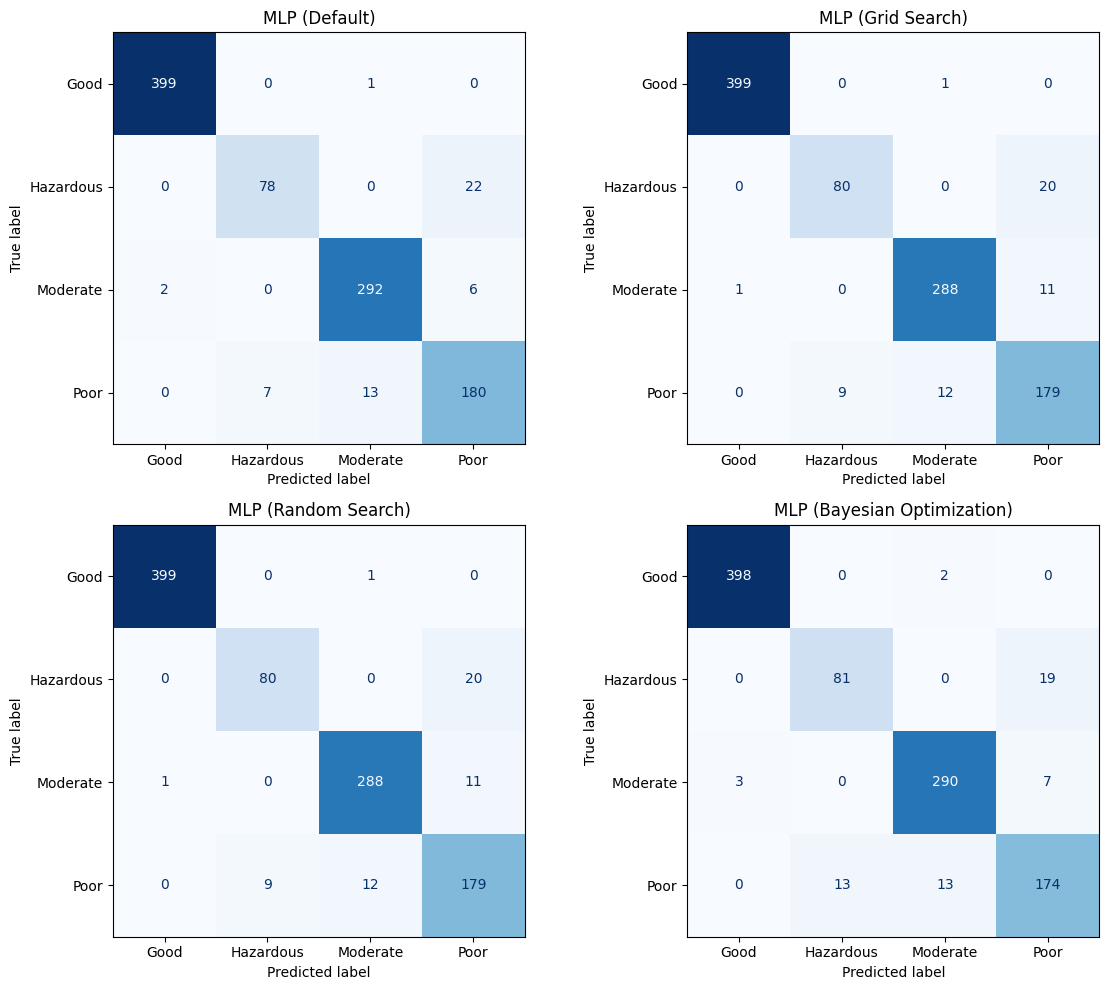

In [65]:
# ==============================
# Step 12: Comparing Confusion Matrix
# ==============================

# Collect predictions from all trained models
predictions = {
    "MLP (Default)": y_test_pred_default,              # Predictions from default model
    "MLP (Grid Search)": y_test_pred_grid,             # Predictions from grid search model
    "MLP (Random Search)": y_test_pred_random,         # Predictions from random search model
    "MLP (Bayesian Optimization)": y_test_pred_bayes   # Predictions from Bayesian model
}

# Create a 2x2 subplot layout for confusion matrices
fig, axes = plt.subplots(
    nrows = 2,                                         # Two rows
    ncols = 2,                                         # Two columns
    figsize = (12, 10)                                 # Figure size
)

axes = axes.flatten()                                  # Flatten axes for easy iteration

# Plot confusion matrix for each model
for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,                                        # True labels
        y_pred,                                        # Predicted labels
        display_labels = label_encoder.classes_,       # Original class names
        cmap = "Blues",                                # Color map
        values_format = "d",                           # Show counts
        ax = ax,                                       # Plot on specific subplot
        colorbar = False                               # Remove color bar
    )
    ax.set_title(model_name)                           # Set subplot title

plt.tight_layout()                                     # Adjust layout spacing
plt.show()